## 1. Data preprocessing

In [4]:
import pandas as pd

data_path = "../data/Law/"
df = pd.read_csv(data_path + "law_dataset.csv")
df.reset_index(drop=True, inplace=True)


In [5]:
# # NOTEARS and ReX require numeric, complete matrices, so missing data must be resolved.
# df = df.fillna(df.median())

print(df.shape)
df = df.dropna()
df.head()

print(df.shape)

(18692, 12)
(18692, 12)


In [6]:
# Only supports numeric input. Categorical features must be encoded numerically.
df.dtypes

decile1b    float64
decile3     float64
lsat        float64
ugpa        float64
zfygpa      float64
zgpa        float64
fulltime    float64
faminc      float64
male        float64
racetxt       int64
tier          int64
passbar       int64
dtype: object

In [7]:
pd.value_counts(df['passbar'])

/var/folders/4x/nynq10qj2kz8_zbvh7mnk0y00000gn/T/ipykernel_78567/4170676477.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['passbar'])


passbar
1    16856
0     1836
Name: count, dtype: int64

In [8]:
df.describe()

,decile1b,decile3,lsat,ugpa,zfygpa,zgpa,fulltime,faminc,male,racetxt,tier,passbar
count,18692.000000,18692.000000,18692.000000,18692.000000,18692.000000,18692.000000,18692.000000,18692.000000,18692.000000,18692.000000,18692.000000,18692.000000
mean,5.709608,5.729991,36.990798,3.236342,0.145970,0.080556,1.073882,3.498342,0.564413,0.935748,3.702814,0.901776
std,2.838055,2.830736,5.278948,0.409585,0.921654,0.977962,0.261586,0.833818,0.495847,0.245208,1.115984,0.297625
min,1.000000,1.000000,11.000000,1.500000,-3.350000,-6.440000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,3.000000,3.000000,34.000000,3.000000,-0.480000,-0.600000,1.000000,3.000000,0.000000,1.000000,3.000000,1.000000
50%,6.000000,6.000000,37.000000,3.300000,0.140000,0.080000,1.000000,4.000000,1.000000,1.000000,4.000000,1.000000
75%,8.000000,8.000000,41.000000,3.500000,0.780000,0.760000,1.000000,4.000000,1.000000,1.000000,4.000000,1.000000
max,10.000000,10.000000,48.000000,4.000000,3.480000,4.010000,2.000000,5.000000,1.000000,1.000000,6.000000,1.000000


In [9]:
# # Continuous numeric features should be scaled. Recommended for NOTEARS (sensitive to magnitude)

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# df_scaled = pd.DataFrame(
#     scaler.fit_transform(df),
#     columns=df.columns
# )

# df_scaled.head()

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


class LawDataPreprocessor:
    """
    Preprocessing pipeline for Law dataset
    Causal discovery–ready (ReX / NOTEARS / PC / GES)
    """

    def __init__(
        self,
        path,
        test_size=0.2,
        random_state=42,
        subsample_ratio=1.0,  # 1.0 = balanced, None = full dataset
    ):
        self.path = path
        self.test_size = test_size
        self.random_state = random_state
        self.subsample_ratio = subsample_ratio

        self.target = "passbar"

        # --------------------
        # Variable definitions
        # --------------------

        # Context (protected / non-actionable)
        self.context_vars = ["male", "racetxt"]

        # Actionable numeric variables
        self.numeric_vars = [
            "lsat",
            "ugpa",
            "zfygpa",
            "zgpa",
            "faminc",
            "decile1b",
            "decile3",
            "fulltime",
        ]

        # NOTE: add context variables ["male", "racetxt"] as categorical_vars
        # Actionable categorical variables
        self.categorical_vars = ["tier", "male", "racetxt"]

        self.causal_graph_vars = self.numeric_vars + self.categorical_vars

        self._build_pipeline()

    # ------------------------------------------------------------------
    # Pipeline
    # ------------------------------------------------------------------
    def _build_pipeline(self):
        self.pipeline = ColumnTransformer(
            transformers=[
                (
                    "numeric",
                    Pipeline(
                        steps=[
                            ("impute", SimpleImputer(strategy="median")),
                            ("scale", StandardScaler()),
                        ]
                    ),
                    self.numeric_vars,
                ),
                (
                    "categorical",
                    Pipeline(
                        steps=[
                            ("impute", SimpleImputer(strategy="most_frequent")),
                            (
                                "encode",
                                OrdinalEncoder(
                                    handle_unknown="use_encoded_value", unknown_value=-1
                                ),
                            ),
                        ]
                    ),
                    self.categorical_vars,
                ),
            ],
            remainder="drop",
        )

    # ------------------------------------------------------------------
    # Main API
    # ------------------------------------------------------------------
    def load_and_process(self):
        df = pd.read_csv(self.path + "law_dataset.csv")

        # --------------------
        # Drop missing
        # --------------------
        df = df.dropna().reset_index(drop=True)

        # --------------------
        # Target
        # --------------------
        y = df[self.target].astype(int).values

        # --------------------
        # Context encoding
        # --------------------
        context = df[self.context_vars].copy().astype(int)

        # --------------------
        # Features for causal discovery
        # --------------------
        X = df[self.causal_graph_vars].copy()

        # --------------------
        # Optional subsampling to balance classes
        # --------------------
        if self.subsample_ratio is not None:
            rng = np.random.default_rng(self.random_state)

            idx_pos = np.where(y == 1)[0]
            idx_neg = np.where(y == 0)[0]

            n_pos = min(int(len(idx_neg) * self.subsample_ratio), len(idx_pos))
            idx_pos_sub = rng.choice(idx_pos, size=n_pos, replace=False)

            idx_sub = np.concatenate([idx_pos_sub, idx_neg])
            idx_sub = rng.permutation(idx_sub)

            X = X.iloc[idx_sub].reset_index(drop=True)
            y = y[idx_sub]
            context = context.iloc[idx_sub].reset_index(drop=True)

        # --------------------
        # Train / test split
        # --------------------
        X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
            X,
            y,
            context,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y,
        )

        # --------------------
        # Fit + transform
        # --------------------
        X_train = self.pipeline.fit_transform(X_train)
        X_test = self.pipeline.transform(X_test)

        self.feature_names_ = self.causal_graph_vars

        # --------------------
        # Report
        # --------------------
        print("\n" + "-" * 80)
        print("Law dataset summary")
        print(f"Samples: {len(y)}")
        print(f"Pass: {y.sum()} | Fail: {(1 - y).sum()}")
        print(f"male=1: {context['male'].sum()}")
        print(f"race=1: {context['racetxt'].sum()}")
        print("-" * 80 + "\n")

        return {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "context_train": c_train.values,
            "context_test": c_test.values,
            "feature_names": self.feature_names_,
        }


In [21]:
data = LawDataPreprocessor(data_path)
data_processed = data.load_and_process()

print("X_train shape:", data_processed["X_train"].shape)
print("feature_names:", data.feature_names_)
print("Positive class rate:", data_processed["y_train"].mean())


--------------------------------------------------------------------------------
Law dataset summary
Samples: 3672
Pass: 1836 | Fail: 1836
male=1: 1996
race=1: 3127
--------------------------------------------------------------------------------

X_train shape: (2937, 11)
feature_names: ['lsat', 'ugpa', 'zfygpa', 'zgpa', 'faminc', 'decile1b', 'decile3', 'fulltime', 'tier', 'male', 'racetxt']
Positive class rate: 0.5001702417432754


In [22]:
train_processed = pd.DataFrame(data_processed['X_train'], columns=data_processed['feature_names'])

train_processed.to_csv("./data_processed/law_processed_downsampled.csv", index=False)

In [23]:
train_processed

,lsat,ugpa,zfygpa,zgpa,faminc,decile1b,decile3,fulltime,tier,male,racetxt
0,-1.4929,-0.7802,-0.1467,-0.9865,-1.6407,-0.1665,-1.1699,-0.3348,2.0000,0.0000,0.0000
1,-0.3146,0.3642,0.1136,0.8837,0.6883,0.1821,0.9188,-0.3348,2.0000,0.0000,1.0000
2,0.3586,-1.0090,0.3219,0.4767,-0.4762,0.1821,0.5707,-0.3348,2.0000,0.0000,1.0000
3,-0.1463,0.3642,-0.0738,-0.2016,-0.4762,-0.1665,-0.4736,-0.3348,3.0000,1.0000,1.0000
4,-0.4830,0.8220,-0.3133,0.0988,-0.4762,-0.5151,-0.1255,-0.3348,2.0000,0.0000,1.0000
...,...,...,...,...,...,...,...,...,...,...,...
2932,-0.6513,0.3642,-0.6257,-0.2016,0.6883,-0.8638,-0.4736,-0.3348,1.0000,0.0000,1.0000
2933,0.1903,0.5931,0.0095,-0.0175,-0.4762,-0.1665,-0.1255,-0.3348,2.0000,1.0000,1.0000
2934,-0.3146,-0.3224,0.3531,0.7384,0.6883,0.5307,0.9188,-0.3348,2.0000,1.0000,1.0000
2935,0.3586,1.5087,0.2802,0.3217,0.6883,0.1821,0.2226,2.9870,1.0000,1.0000,1.0000


## 2. Causal discovery models

In [24]:
from causalexplain import GraphDiscovery

# Create experiment object
gd = GraphDiscovery(
    experiment_name="law_causal",
    model_type="rex",               
    csv_filename="./data_processed/law_processed_downsampled.csv", # your dataset
)

### 2.1 With no prior constraints

In [25]:
# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

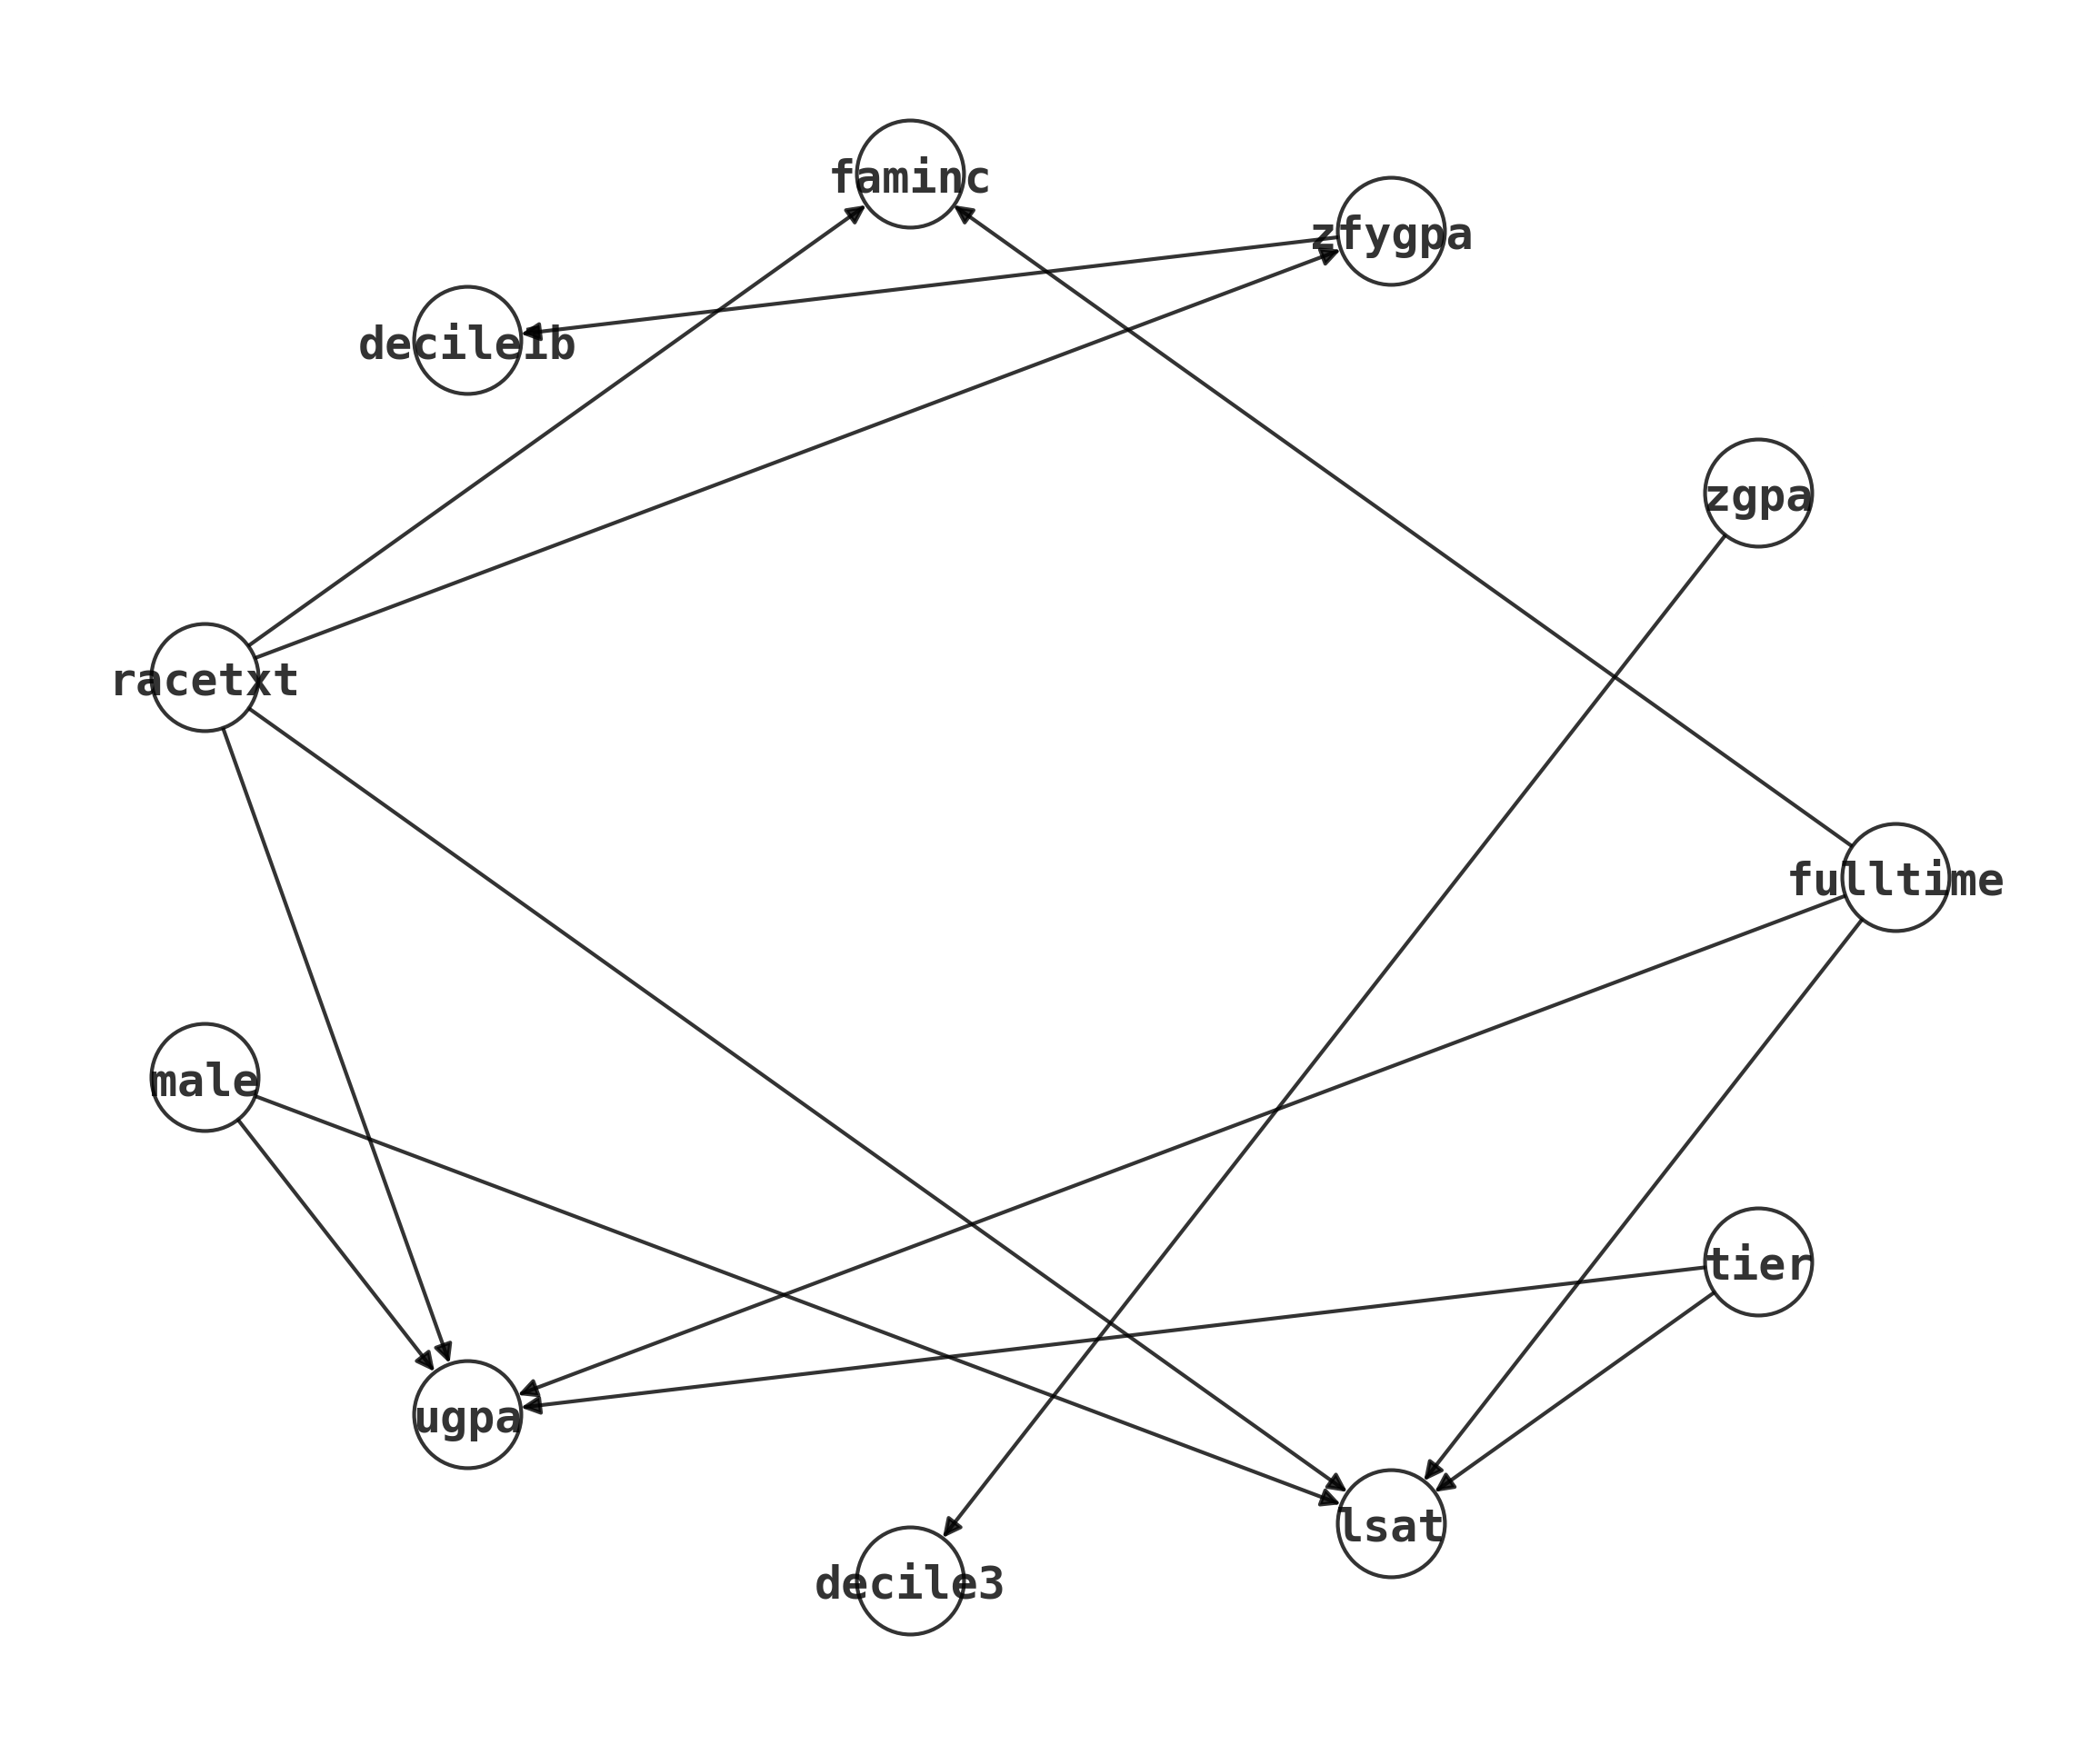

In [26]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [28]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_law/law_rex3_no_constraints.dot") 

### 2.2 With 4-tier prior constraints

In [29]:
# Context (Tier 0)
# male, racetxt
# Root causes; nothing causes these. They can influence everything else.

# Academic background (Tier 1)
# lsat, ugpa, faminc
# Pre-admission factors. LSAT/UGPA determine law school admission; fam income shapes prep access.

# Law school environment (Tier 2)
# tier (law school ranking), fulltime
# Determined by admission (LSAT, UGPA, faminc) and personal choice.

# Law school performance (Tier 3)
# zfygpa, zgpa, decile1b, decile3
# Outcomes during law school; influenced by Tier 1 + Tier 2.

prior = [
    ["male", "racetxt"],                     # Tier 0: context
    ["lsat", "ugpa", "faminc"],             # Tier 1: academic background
    ["tier", "fulltime"],                    # Tier 2: school / program
    ["zfygpa", "zgpa", "decile1b", "decile3"] # Tier 3: law performance
]


In [30]:
# NOTE: run with constraints: prior

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)



Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

In [31]:
# Numbers of trainer from REX
print(gd.trainer)
print()

# SHAP sampling summary
print(gd._sampling_summary())

{'law_processed_downsampled_nn': <causalexplain.common.notebook.Experiment object at 0x3349105c0>, 'law_processed_downsampled_gbt': <causalexplain.common.notebook.Experiment object at 0x35d373d10>, 'law_processed_downsampled_rex': <causalexplain.common.notebook.Experiment object at 0x357e729f0>}

SHAP adaptive sampling: multi_sample (K=5, samples=512)


In [32]:
import networkx as nx

print(gd.dag.number_of_nodes())
print(gd.dag.number_of_edges())

11
4


In [33]:
# Adjacency matrix
import pandas as pd

adj_df = pd.DataFrame(
    nx.to_numpy_array(gd.dag, nodelist=gd.data_columns),
    index=gd.data_columns,
    columns=gd.data_columns
)

adj_df

,lsat,ugpa,zfygpa,zgpa,faminc,decile1b,decile3,fulltime,tier,male,racetxt
lsat,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
ugpa,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
zfygpa,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
zgpa,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
faminc,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
decile1b,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
decile3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
fulltime,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
tier,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
male,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


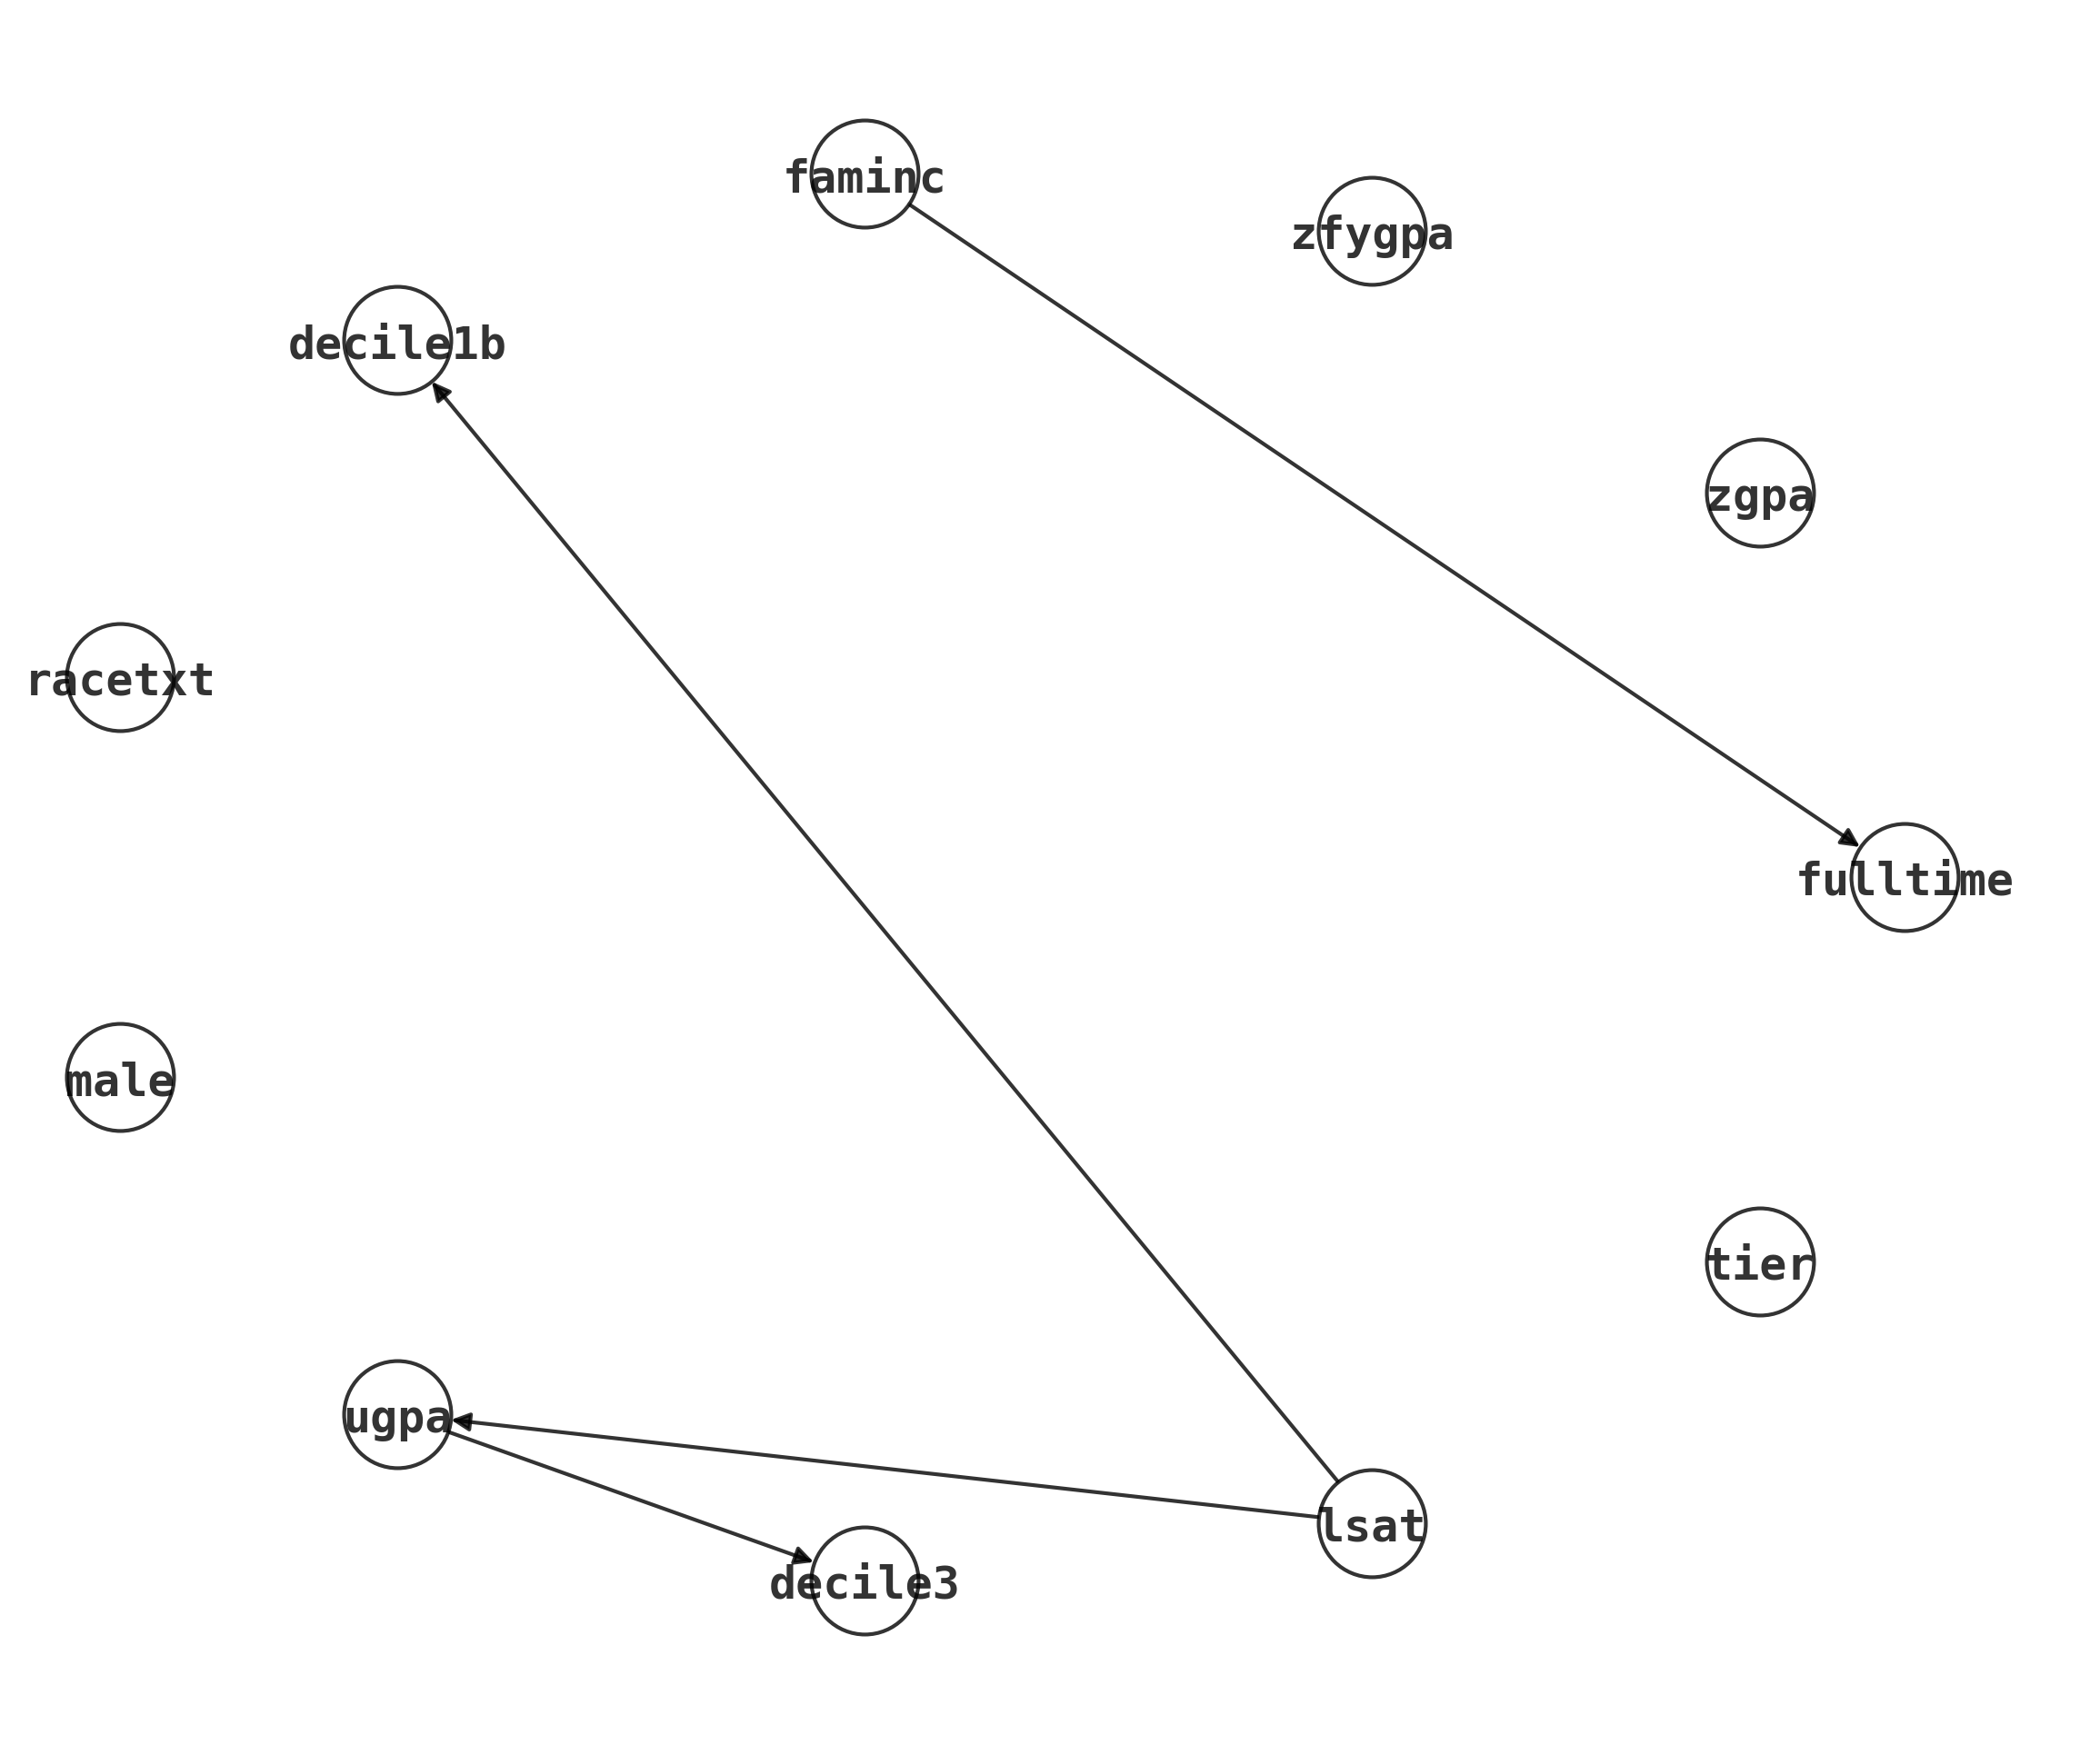

In [34]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [32]:
# gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [35]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_law/law_rex4_constraints.dot")

### 2.3 With minimal prior constraints

In [38]:
prior_minimal = [
    ["male", "racetxt"],                     # Tier 0: context
    ["lsat", "ugpa", "faminc", "tier", "fulltime",
     "zfygpa", "zgpa", "decile1b", "decile3"], # Tier 1: everything else
]

In [39]:
# NOTE: run with constraints: prior_minimal

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior_minimal,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

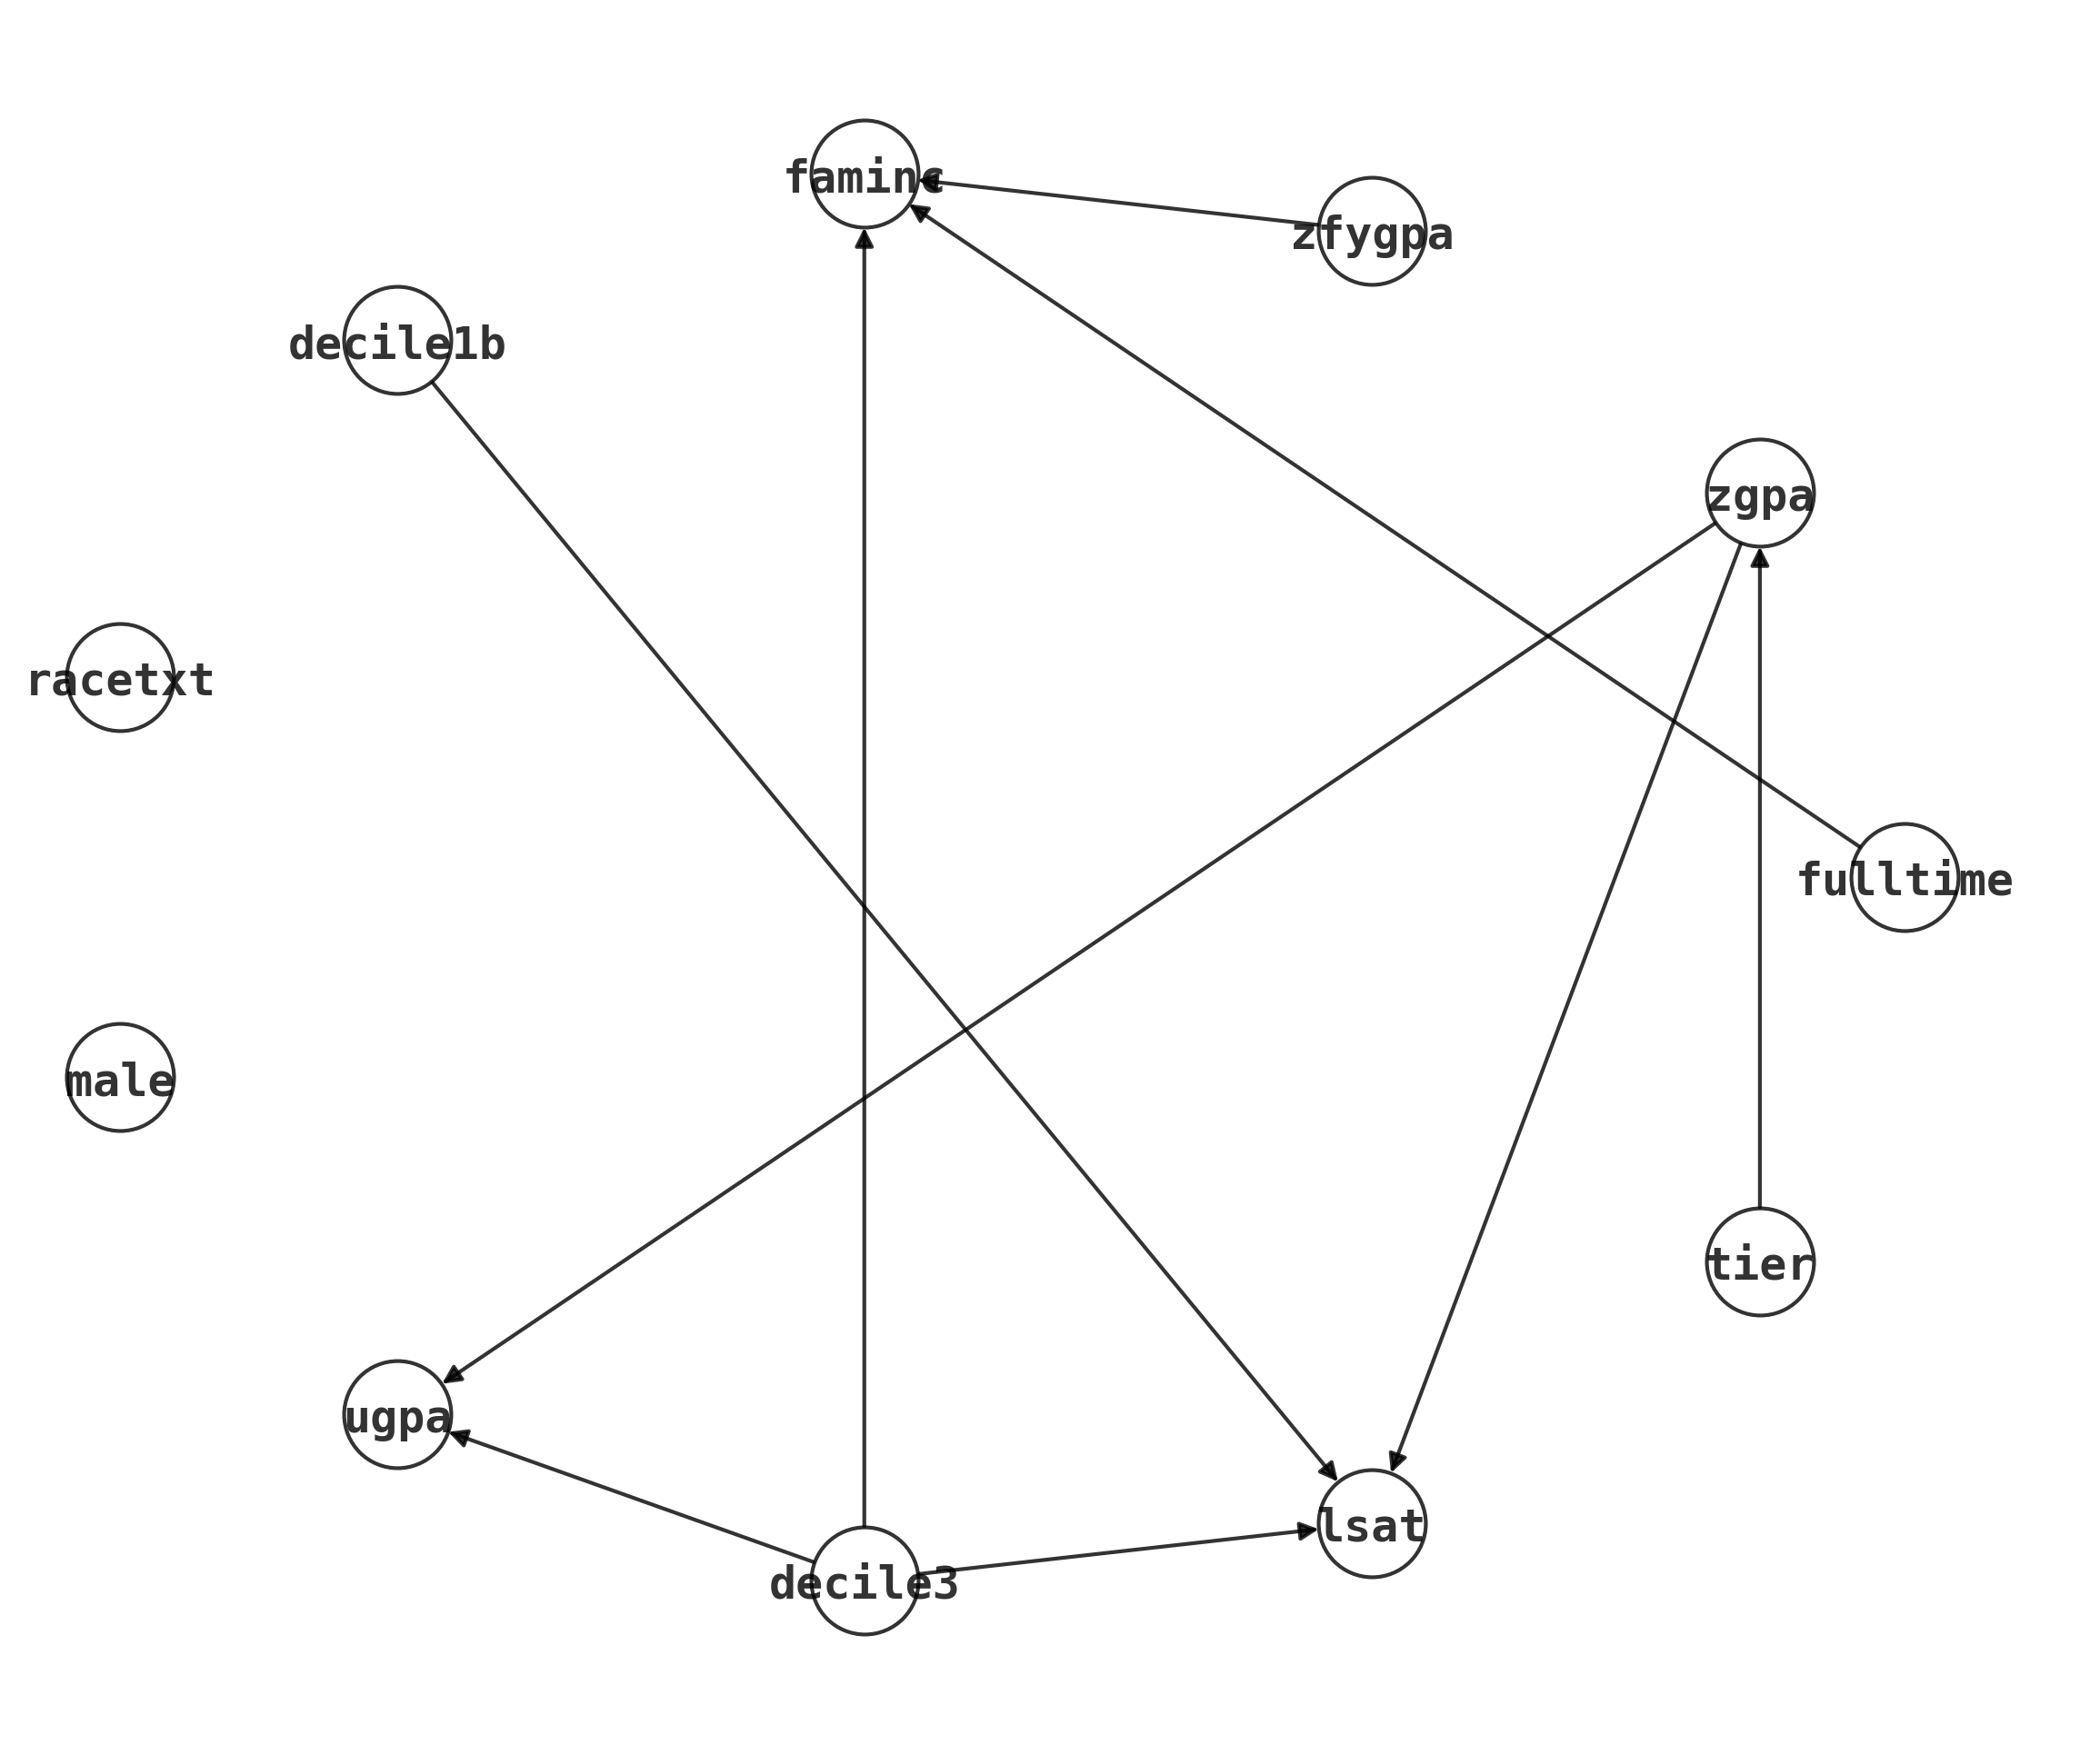

In [40]:
# Plot or inspect the learned graph
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [41]:
# gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [42]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_law/law_rex5_constraints_min.dot")

### 2.4 With moderate prior constraints

In [43]:
prior_mod = [
    ["male", "racetxt"],                     # Tier 0: context
    ["lsat", "ugpa", "faminc", "tier", "fulltime"], # Tier 1: background + environment
    ["zfygpa", "zgpa", "decile1b", "decile3"], # Tier 2: performance + outcome
]

In [44]:
# NOTE: run with constraints: prior_minimal

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior_mod,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

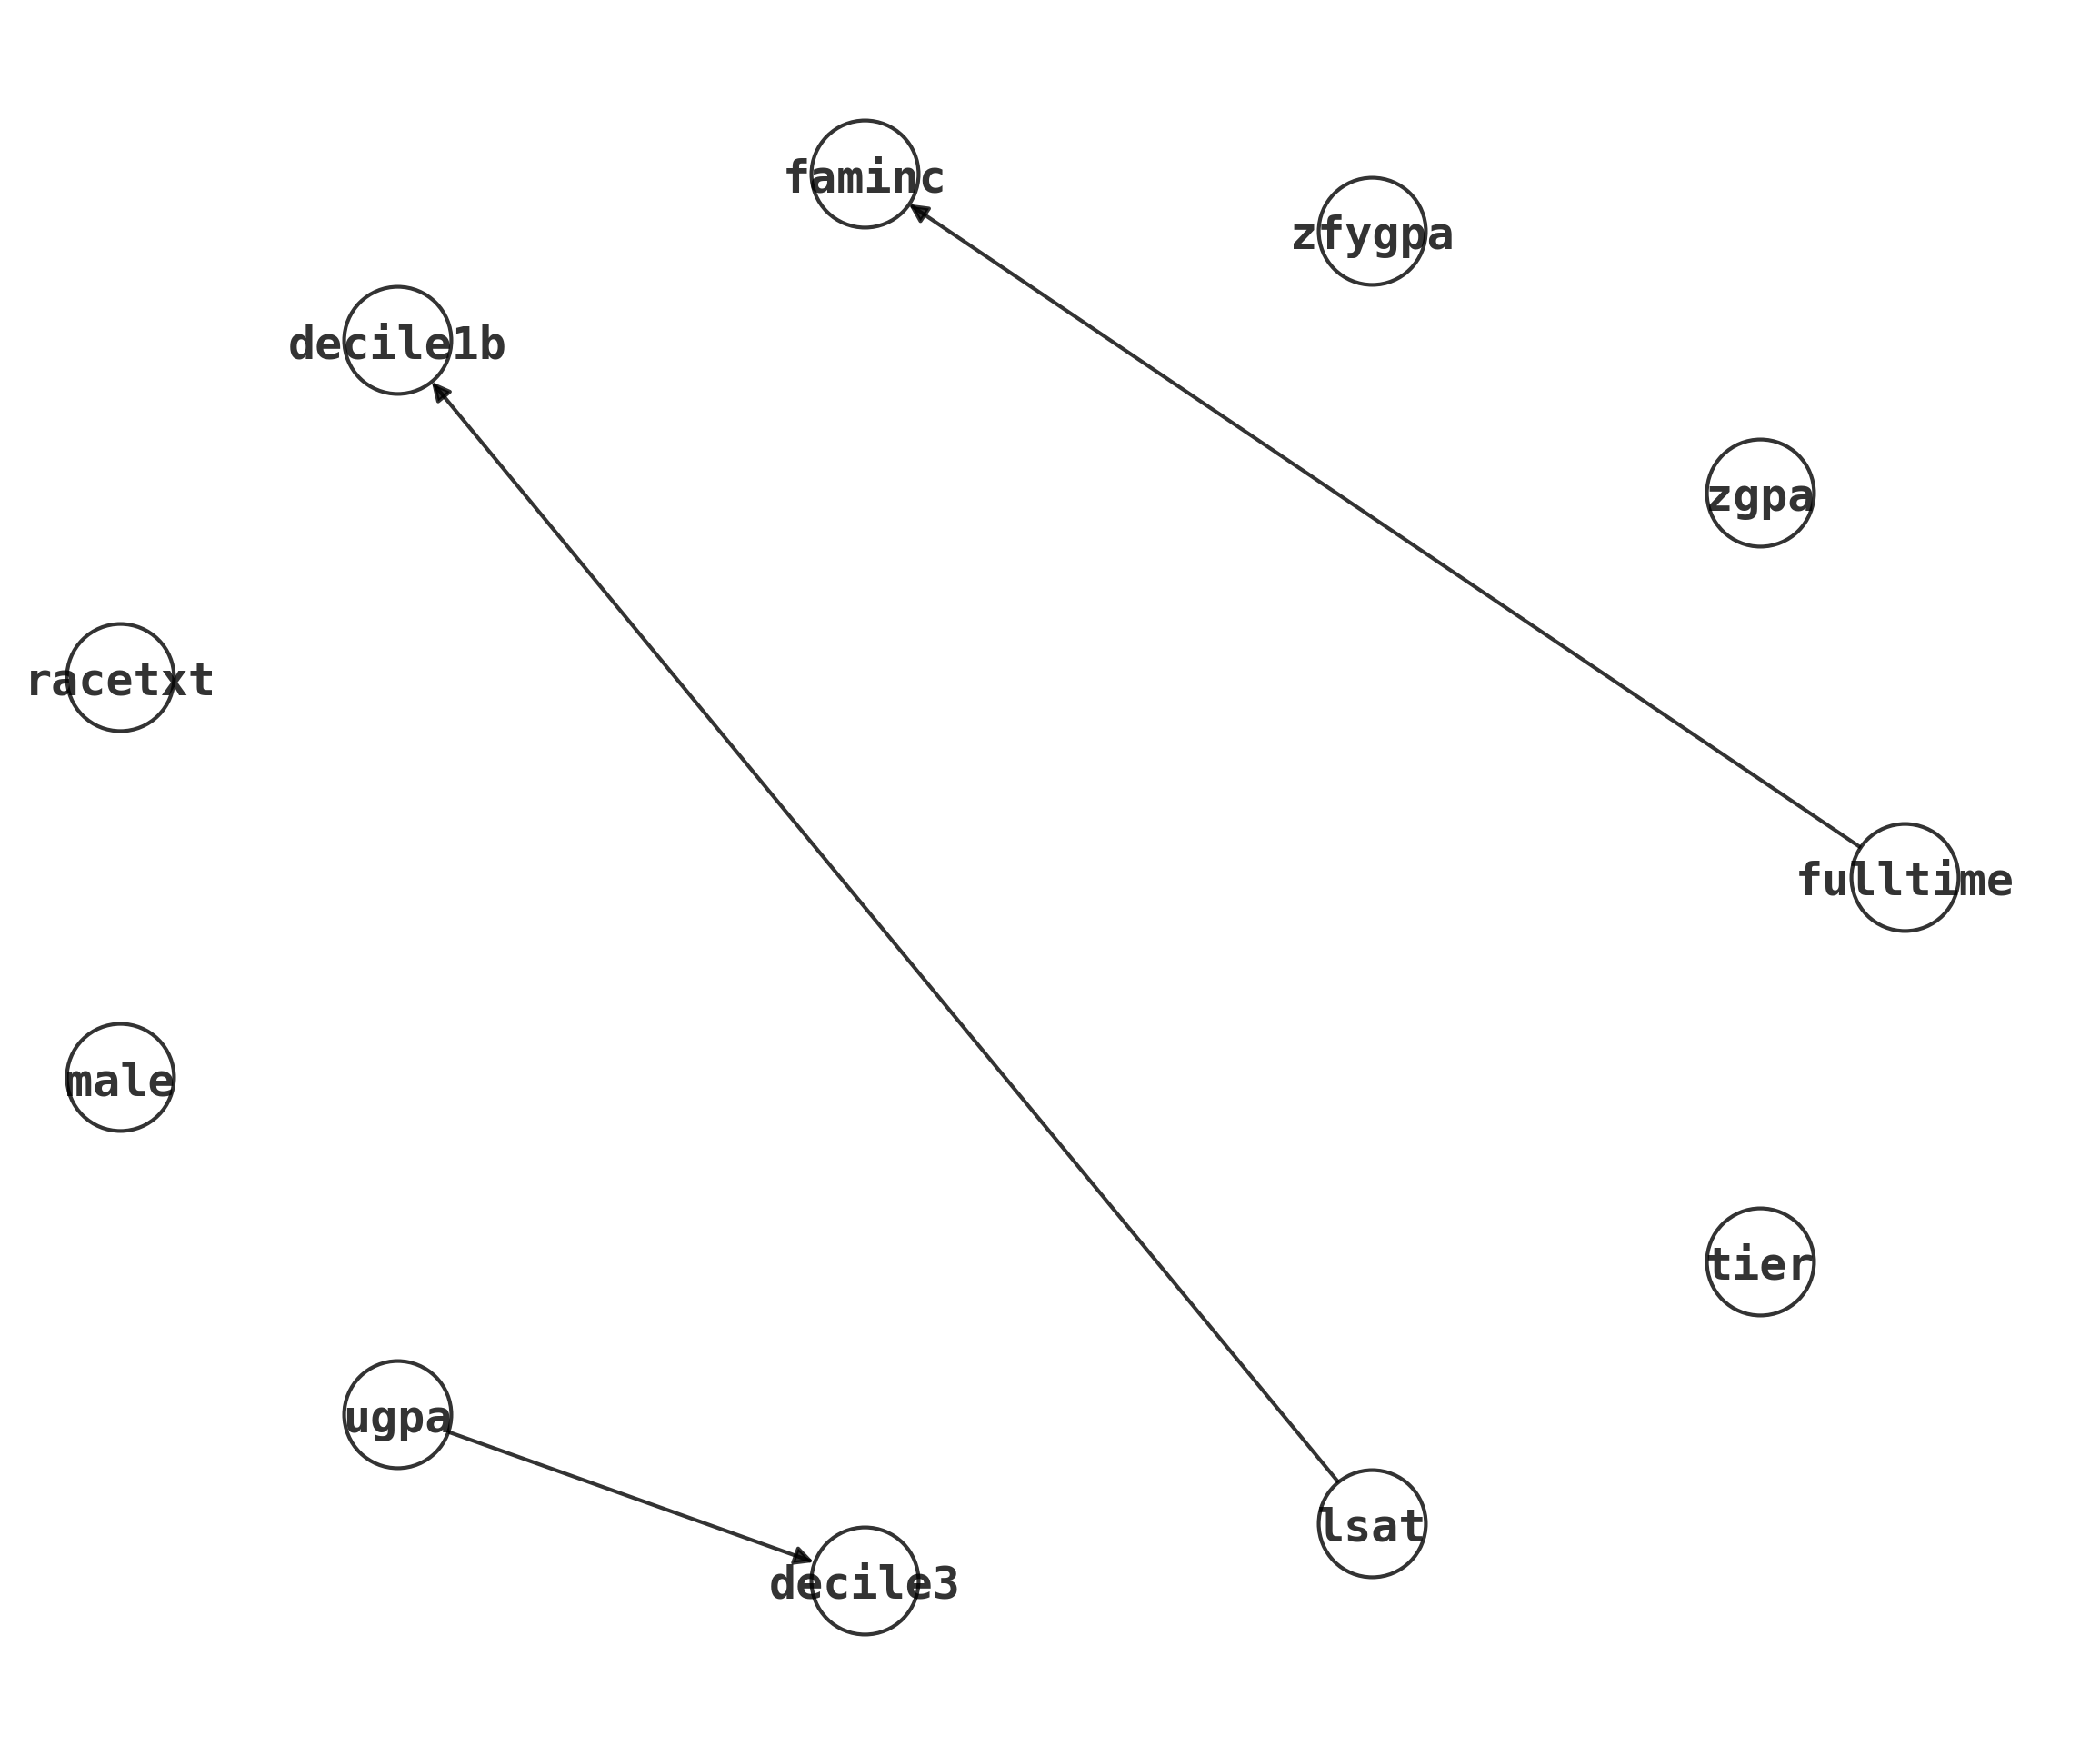

In [45]:
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [46]:
# Save the learned model & export DOT format
gd.export("./causal_graphs_law/law_rex6_constraints_mod.dot")